# PRCP-1006: Home Loan Default Prediction Project

---

## Project Objective
* **Task 1**: Prepare a complete data analysis report on the given Home Loan data.
* **Task 2**: Create a model predicting potential Home Loan Defaults using Machine Learning algorithms.
* **Task 3**: Provide business suggestions to reduce loan-default risk.
* **Reporting**: Provide a Model Comparison Report and a Report on Challenges Faced.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Put all 7 CSV files inside this folder
DATA_FOLDER = 'Home Loan'

files = {'application': 'application_train.csv',
         'bureau': 'bureau.csv',
         'bureau_balance': 'bureau_balance.csv',
         'previous': 'previous_application.csv',
         'pos_cash': 'POS_CASH_balance.csv',
         'credit_card': 'credit_card_balance.csv',
         'installments': 'installments_payments.csv'}

for name, file in files.items():
    path = os.path.join(DATA_FOLDER, file)
    print(name, '->', 'Found' if os.path.exists(path) else 'NOT FOUND')

# Main application data
base_cols = ['SK_ID_CURR', 'TARGET',
             'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
             'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
             'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'REGION_POPULATION_RELATIVE',
             'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
             'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

df = pd.read_csv(os.path.join(DATA_FOLDER, files['application']),usecols=base_cols)

# Simple feature engineering
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan)
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365
df['EMPLOYED_YEARS'] = np.where(df['DAYS_EMPLOYED'] < 0, -df['DAYS_EMPLOYED'] / 365, 0)

# Simple reusable function for the large history files
def add_group_features(base_df, file_name, key, agg_dict, prefix):
    temp = pd.read_csv(os.path.join(DATA_FOLDER, file_name),
                       usecols=[key] + list(agg_dict.keys()))

    grouped = temp.groupby(key).agg(agg_dict)

    # Make simple column names
    if isinstance(grouped.columns, pd.MultiIndex):
        grouped.columns = [
            f'{prefix}_{col}_{stat}'
            for col, stat in grouped.columns.to_flat_index()
        ]
    else:
        grouped.columns = [f'{prefix}_{col}' for col in grouped.columns]

    grouped = grouped.reset_index()
    return base_df.merge(grouped, on=key, how='left')

# Aggregate the large history files to one row per customer
df = add_group_features(
    df,
    files['bureau'],
    'SK_ID_CURR',
    {
        'SK_ID_BUREAU': ['nunique'],
        'AMT_CREDIT_SUM': ['mean'],
        'AMT_CREDIT_SUM_DEBT': ['mean'],
        'CREDIT_DAY_OVERDUE': ['max']
    },
    'BUREAU'
)

df = add_group_features(
    df,
    files['previous'],
    'SK_ID_CURR',
    {
        'SK_ID_PREV': ['nunique'],
        'AMT_APPLICATION': ['mean'],
        'AMT_CREDIT': ['mean'],
        'AMT_ANNUITY': ['mean']
    },
    'PREVIOUS'
)

df = add_group_features(
    df,
    files['pos_cash'],
    'SK_ID_CURR',
    {
        'SK_ID_PREV': ['nunique'],
        'CNT_INSTALMENT': ['mean'],
        'SK_DPD': ['max']
    },
    'POS'
)

df = add_group_features(
    df,
    files['credit_card'],
    'SK_ID_CURR',
    {
        'SK_ID_PREV': ['nunique'],
        'AMT_BALANCE': ['mean'],
        'AMT_CREDIT_LIMIT_ACTUAL': ['mean'],
        'SK_DPD': ['max']
    },
    'CC'
)

df = add_group_features(
    df,
    files['installments'],
    'SK_ID_CURR',
    {
        'SK_ID_PREV': ['nunique'],
        'AMT_INSTALMENT': ['mean'],
        'AMT_PAYMENT': ['mean'],
        'DAYS_ENTRY_PAYMENT': ['mean']
    },
    'INST'
)

print('Final modeling table:', df.shape)

application -> Found
bureau -> Found
bureau_balance -> Found
previous -> Found
pos_cash -> Found
credit_card -> Found
installments -> Found
Final modeling table: (307511, 41)


In [3]:
df.head()

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,POS_CNT_INSTALMENT_mean,POS_SK_DPD_max,CC_SK_ID_PREV_nunique,CC_AMT_BALANCE_mean,CC_AMT_CREDIT_LIMIT_ACTUAL_mean,CC_SK_DPD_max,INST_SK_ID_PREV_nunique,INST_AMT_INSTALMENT_mean,INST_AMT_PAYMENT_mean,INST_DAYS_ENTRY_PAYMENT_mean
0,100002,1,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,24.000000,0.0,NaN,NaN,NaN,NaN,1.0,11559.247105,11559.247105,-315.421053
1,100003,0,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,10.107143,0.0,NaN,NaN,NaN,NaN,3.0,64754.586000,64754.586000,-1385.320000
2,100004,0,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,3.750000,0.0,NaN,NaN,NaN,NaN,1.0,7096.155000,7096.155000,-761.666667
3,100006,0,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,12.000000,0.0,1.0,0.0,270000.0,0.0,3.0,62947.088438,62947.088438,-271.625000
4,100007,0,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,15.333333,0.0,NaN,NaN,NaN,NaN,5.0,12666.444545,12214.060227,-1032.242424


In [4]:
df.shape

(307511, 41)

In [5]:
df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 41 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   SK_ID_CURR                       307511 non-null  int64  
 1   TARGET                           307511 non-null  int64  
 2   CODE_GENDER                      307511 non-null  object 
 3   FLAG_OWN_CAR                     307511 non-null  object 
 4   FLAG_OWN_REALTY                  307511 non-null  object 
 5   CNT_CHILDREN                     307511 non-null  int64  
 6   AMT_INCOME_TOTAL                 307511 non-null  float64
 7   AMT_CREDIT                       307511 non-null  float64
 8   AMT_ANNUITY                      307499 non-null  float64
 9   AMT_GOODS_PRICE                  307233 non-null  float64
 10  NAME_EDUCATION_TYPE              307511 non-null  object 
 11  NAME_FAMILY_STATUS               307511 non-null  object 
 12  RE

In [7]:
df.isnull().sum().sort_values(ascending=False).head(20)

CC_SK_ID_PREV_nunique              220606
CC_SK_DPD_max                      220606
CC_AMT_CREDIT_LIMIT_ACTUAL_mean    220606
CC_AMT_BALANCE_mean                220606
EXT_SOURCE_3                        60965
BUREAU_AMT_CREDIT_SUM_DEBT_mean     51380
BUREAU_AMT_CREDIT_SUM_mean          44021
BUREAU_SK_ID_BUREAU_nunique         44020
BUREAU_CREDIT_DAY_OVERDUE_max       44020
POS_CNT_INSTALMENT_mean             18091
POS_SK_DPD_max                      18067
POS_SK_ID_PREV_nunique              18067
PREVIOUS_AMT_ANNUITY_mean           16871
PREVIOUS_AMT_CREDIT_mean            16454
PREVIOUS_AMT_APPLICATION_mean       16454
PREVIOUS_SK_ID_PREV_nunique         16454
INST_AMT_PAYMENT_mean               15876
INST_DAYS_ENTRY_PAYMENT_mean        15876
INST_SK_ID_PREV_nunique             15868
INST_AMT_INSTALMENT_mean            15868
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,1.000020e+05,189145.500000,278202.000000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-1.791200e+04,-2760.000000,-1213.000000,-289.000000,3.652430e+05


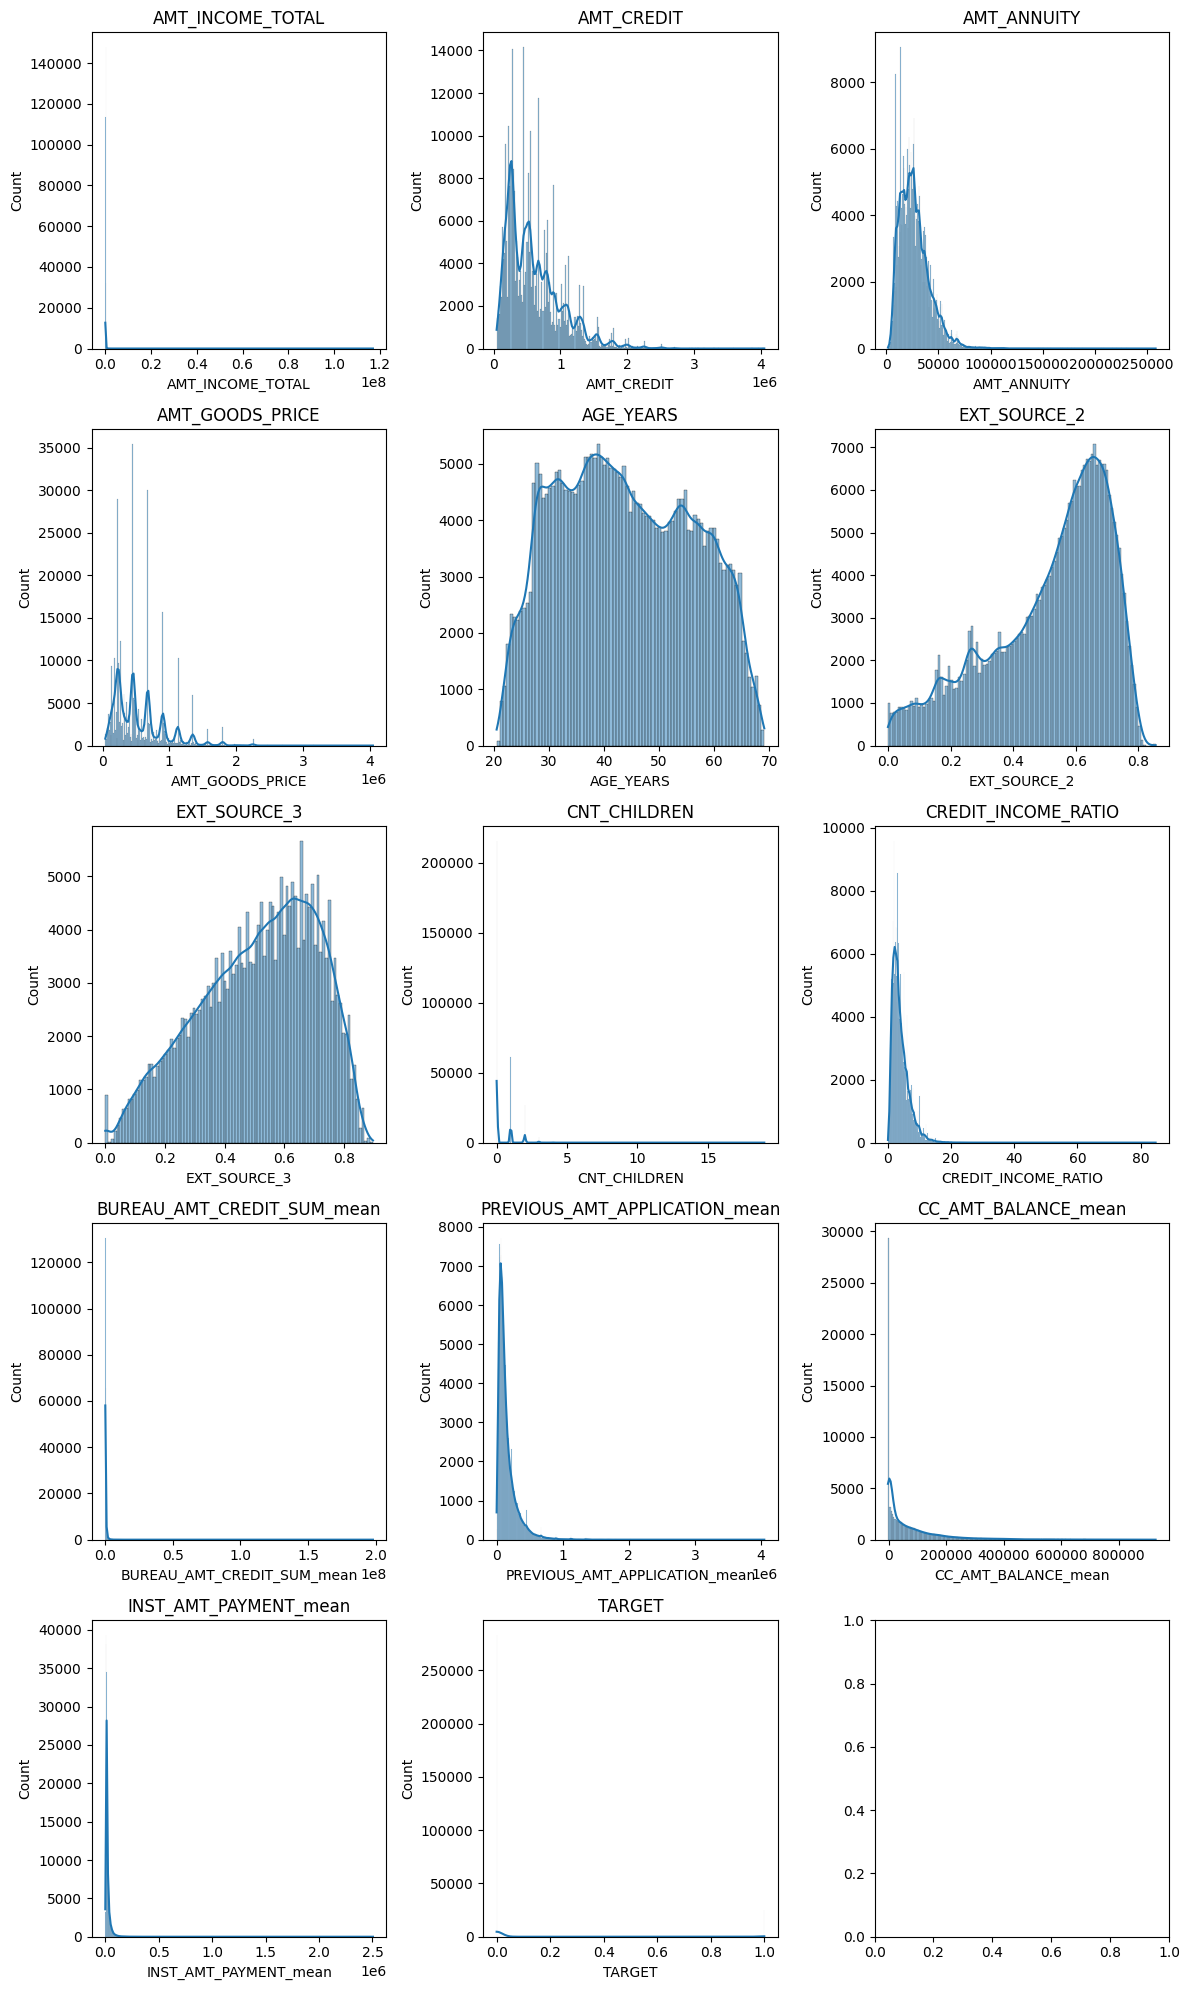

In [32]:
plot_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'AMT_GOODS_PRICE', 'AGE_YEARS', 'EXT_SOURCE_2',
    'EXT_SOURCE_3', 'CNT_CHILDREN', 'CREDIT_INCOME_RATIO',
    'BUREAU_AMT_CREDIT_SUM_mean', 'PREVIOUS_AMT_APPLICATION_mean',
    'CC_AMT_BALANCE_mean', 'INST_AMT_PAYMENT_mean', 'TARGET'
]

fig, axes = plt.subplots(5, 3, figsize=(12, 20))

for col, ax in zip(plot_cols, axes.flat):
    sns.histplot(df, x=col, kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

* **TARGET** is the loan-default target, where `1` indicates default and `0` indicates non-default.
* **Income, credit and annuity** describe the applicant's main loan application.
* **EXT_SOURCE_2 and EXT_SOURCE_3** provide external credit-score information.
* **Bureau, previous application, POS cash, credit-card and installment data** are converted into customer-level summary features.
* Missing values are expected because not every applicant has every type of previous credit history.


In [ ]:
X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

In [34]:
# Correlation is mainly useful for the numeric columns
X.corr(numeric_only=True)

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,EXT_SOURCE_2,...,POS_CNT_INSTALMENT_mean,POS_SK_DPD_max,CC_SK_ID_PREV_nunique,CC_AMT_BALANCE_mean,CC_AMT_CREDIT_LIMIT_ACTUAL_mean,CC_SK_DPD_max,INST_SK_ID_PREV_nunique,INST_AMT_INSTALMENT_mean,INST_AMT_PAYMENT_mean,INST_DAYS_ENTRY_PAYMENT_mean
CNT_CHILDREN,1.000000,0.012882,0.002145,0.021374,-0.001827,-0.025573,0.330938,-0.239818,0.879161,-0.018015,...,-0.067826,-0.002610,-0.005804,0.019590,-0.001254,-0.003852,-0.010698,-0.022885,-0.024342,-0.006075
AMT_INCOME_TOTAL,0.012882,1.000000,0.156870,0.191657,0.159610,0.074796,0.027261,-0.064223,0.016342,0.060925,...,0.020452,-0.001976,0.002917,0.089436,0.116613,-0.013371,0.018248,0.080162,0.079131,-0.002086
AMT_CREDIT,0.002145,0.156870,1.000000,0.770138,0.986968,0.099738,-0.055436,-0.066838,0.063160,0.131228,...,0.037866,0.007104,-0.000595,-0.021349,0.016585,0.013577,0.025810,0.157394,0.159906,-0.084072
AMT_ANNUITY,0.021374,0.191657,0.770138,1.000000,0.775109,0.118429,0.009445,-0.104332,0.075539,0.125804,...,-0.023326,0.003748,0.000271,-0.024373,0.014061,0.002495,0.005527,0.178747,0.175477,-0.051272
AMT_GOODS_PRICE,-0.001827,0.159610,0.986968,0.775109,1.000000,0.103520,-0.053442,-0.064842,0.061185,0.139367,...,0.033429,0.007200,0.002150,-0.033409,0.010989,0.013080,0.027938,0.162240,0.165203,-0.084853
REGION_POPULATION_RELATIVE,-0.025573,0.074796,0.099738,0.118429,0.103520,1.000000,-0.029582,-0.003980,-0.024209,0.198924,...,0.009088,0.002869,0.004631,0.026087,0.039571,0.000418,0.008581,0.058651,0.056302,-0.046556
DAYS_BIRTH,0.330938,0.027261,-0.055436,0.009445,-0.053442,-0.029582,1.000000,-0.615864,0.278894,-0.091996,...,-0.170957,-0.019194,-0.003870,0.061074,0.023861,-0.031729,-0.093841,-0.062029,-0.065891,0.099223
DAYS_EMPLOYED,-0.239818,-0.064223,-0.066838,-0.104332,-0.064842,-0.003980,-0.615864,1.000000,-0.233549,-0.020767,...,0.088558,0.005866,0.002375,-0.062041,-0.077490,0.005889,0.047708,-0.003337,-0.000272,-0.012136
CNT_FAM_MEMBERS,0.879161,0.016342,0.063160,0.075539,0.061185,-0.024209,0.278894,-0.233549,1.000000,-0.001823,...,-0.031318,0.001741,-0.003412,0.024797,0.018867,-0.003727,0.010208,0.007253,0.006099,-0.017703
EXT_SOURCE_2,-0.018015,0.060925,0.131228,0.125804,0.139367,0.198924,-0.091996,-0.020767,-0.001823,1.000000,...,0.010902,0.001274,0.001276,-0.010992,0.054204,0.007422,0.015012,0.066618,0.068943,-0.060952


### Correlation Report

After running the coreleation:

* Check which financial variables move together, such as credit amount, income and annuity.
* Check the relationship of `EXT_SOURCE_2` and `EXT_SOURCE_3` with other numeric features.
* Very high correlation between predictors may indicate redundant information.
* Correlation shows association, not causation, so it should be used together with model performance.


### Task 1: Data Analysis Report

* **Dataset Shape**: The main application file contains applicant-level loan records. The history tables are reduced to one row per customer before modeling.
* **Missing Values**: Missing values are handled later using `SimpleImputer`.
* **Duplicates**: Exact duplicate rows are checked before modeling.
* **Class Imbalance**: Home-loan default data contains many more non-default cases than default cases, so class-balanced models are used.
* **Feature Engineering**: Simple ratios and customer-level history summaries are added.
* **Important Point**: Do not judge the model only by accuracy because the target is imbalanced. Recall, F1-score and ROC-AUC are also reported.


In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV

# Remove exact duplicate customer rows if any
df = df.drop_duplicates().copy()

X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print('Training:', X_train.shape)
print('Testing :', X_test.shape)

Training: (246008, 39)
Testing : (61503, 39)
Model comparison sample: (60000, 39)


In [ ]:
# Smaller sample for the 6-model comparison
compare_size = min(60000, len(X_train))

X_train_compare, _, y_train_compare, _ = train_test_split(X_train, y_train,train_size=compare_size,random_state=42,stratify=y_train)

print('Model comparison sample:', X_train_compare.shape)

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_col = X.select_dtypes(include='object').columns
num_col = X.select_dtypes(exclude='object').columns

num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler', StandardScaler())])

cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                     ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num', num_pipe, num_col),
                                               ('cat', cat_pipe, cat_col)])

print('Categorical columns:', list(cat_col))
print('Numeric columns:', len(num_col))

Categorical columns: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']
Numeric columns: 34


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, roc_auc_score
from xgboost import XGBClassifier

results = []

# Class-balanced settings are used instead of SMOTE because the dataset is very large
default_ratio = (y_train_compare == 0).sum() / (y_train_compare == 1).sum()

models = {'LR': Pipeline([('preprocessor', preprocessor),
                          ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))]),
          'KNN': Pipeline([('preprocessor', preprocessor),
                           ('clf', KNeighborsClassifier(n_neighbors=7))]),
          'DT': Pipeline([('preprocessor', preprocessor),
                          ('clf', DecisionTreeClassifier(max_depth=8,class_weight='balanced',random_state=42))]),
          'RF': Pipeline([('preprocessor', preprocessor),
                          ('clf', RandomForestClassifier(n_estimators=150,class_weight='balanced',random_state=42,n_jobs=-1))]),
          'GB': Pipeline([('preprocessor', preprocessor),
                          ('clf', GradientBoostingClassifier(random_state=42))]),
          'XGB': Pipeline([('preprocessor', preprocessor),
                           ('clf', XGBClassifier(n_estimators=150,
                                                 max_depth=5,
                                                 learning_rate=0.05,
                                                 subsample=0.8,
                                                 colsample_bytree=0.8,
                                                 scale_pos_weight=default_ratio,
                                                 eval_metric='logloss',
                                                 tree_method='hist',
                                                 random_state=42))])}

for name, model in models.items():
    model.fit(X_train_compare, y_train_compare)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({'Model': name,
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'Precision': precision_score(y_test, y_pred, zero_division=0),
                    'F1': f1_score(y_test, y_pred, zero_division=0),
                    'Recall': recall_score(y_test, y_pred, zero_division=0),
                    'ROC-AUC': roc_auc_score(y_test, y_prob)})

Training: LR
Training: KNN
Training: DT
Training: RF
Training: GB
Training: XGB


In [15]:
comparison_df = pd.DataFrame(results).set_index('Model')
print(comparison_df.round(4))

       Accuracy  Precision      F1  Recall  ROC-AUC
Model                                              
LR       0.6875     0.1606  0.2597  0.6790   0.7474
KNN      0.9170     0.2680  0.0311  0.0165   0.6189
DT       0.6141     0.1327  0.2222  0.6830   0.6876
RF       0.9193     0.5600  0.0056  0.0028   0.7296
GB       0.9196     0.5736  0.0291  0.0149   0.7547
XGB      0.7259     0.1748  0.2750  0.6439   0.7550


### Model Comparison Report

| Model | Accuracy | Precision | F1 | Recall | ROC-AUC |
| --- | --- | --- | --- | --- | --- |
| **LR** | 0.6875 | 0.1606 | 0.2597 | 0.6790 | 0.7474 |
| **KNN** | 0.9170 | 0.2680 | 0.0311 | 0.0165 | 0.6189 |
| **DT** | 0.6141 | 0.1327 | 0.2222 | 0.6830 | 0.6876 |
| **RF** | 0.9193 | 0.5600 | 0.0056 | 0.0028 | 0.7296 |
| **GB** | 0.9196 | 0.5736 | 0.0291 | 0.0149 | 0.7547 |
| **XGB** | 0.7259 | 0.1748 | 0.2750 | 0.6439 | 0.7550 |

**Why XGBoost was Selected**

1. **Good Recall:** XGBoost has a high Recall of **64.39%**.
2. **Best F1-Score:** XGBoost has the highest F1-score of **0.275** among the models.
3. **Good ROC-AUC:** XGBoost has a high ROC-AUC of **0.755**, showing good classification performance.

In [16]:
# Tune the XGBoost model on the full training data
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(
        scale_pos_weight=default_ratio,
        eval_metric='logloss',
        tree_method='hist',
        random_state=42
    ))
])

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [3, 5],
    'clf__learning_rate': [0.05]
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best parameters:')
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

Best parameters:
{'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 200}


In [17]:
print('Training Accuracy:', accuracy_score(y_train, y_train_pred))
print('Testing Accuracy :', accuracy_score(y_test, y_test_pred))

print('Precision:', precision_score(y_test, y_test_pred, zero_division=0))
print('Recall   :', recall_score(y_test, y_test_pred, zero_division=0))
print('F1 Score :', f1_score(y_test, y_test_pred, zero_division=0))
print('ROC-AUC  :', roc_auc_score(y_test, y_test_prob))

Training Accuracy: 0.7136068745731846
Testing Accuracy : 0.7081443181633417
Precision: 0.1707156261094487
Recall   : 0.6779456193353475
F1 Score : 0.27274937201199256
ROC-AUC  : 0.7614146668976514


In [18]:
def pred_home_loan_default(
    AMT_INCOME_TOTAL,
    AMT_CREDIT,
    AMT_ANNUITY,
    AMT_GOODS_PRICE,
    DAYS_BIRTH,
    DAYS_EMPLOYED,
    EXT_SOURCE_2,
    EXT_SOURCE_3,
    CNT_CHILDREN,
    CNT_FAM_MEMBERS,
    REGION_POPULATION_RELATIVE,
    CODE_GENDER,
    NAME_EDUCATION_TYPE,
    NAME_FAMILY_STATUS,
    FLAG_OWN_CAR,
    FLAG_OWN_REALTY,
    BUREAU_SK_ID_BUREAU_nunique,
    BUREAU_AMT_CREDIT_SUM_mean,
    BUREAU_AMT_CREDIT_SUM_DEBT_mean,
    BUREAU_CREDIT_DAY_OVERDUE_max,
    PREVIOUS_SK_ID_PREV_nunique,
    PREVIOUS_AMT_APPLICATION_mean,
    PREVIOUS_AMT_CREDIT_mean,
    PREVIOUS_AMT_ANNUITY_mean,
    POS_SK_ID_PREV_nunique,
    POS_CNT_INSTALMENT_mean,
    POS_SK_DPD_max,
    CC_SK_ID_PREV_nunique,
    CC_AMT_BALANCE_mean,
    CC_AMT_CREDIT_LIMIT_ACTUAL_mean,
    CC_SK_DPD_max,
    INST_SK_ID_PREV_nunique,
    INST_AMT_INSTALMENT_mean,
    INST_AMT_PAYMENT_mean,
    INST_DAYS_ENTRY_PAYMENT_mean
):
    features = pd.DataFrame([{
        'AMT_INCOME_TOTAL': AMT_INCOME_TOTAL,
        'AMT_CREDIT': AMT_CREDIT,
        'AMT_ANNUITY': AMT_ANNUITY,
        'AMT_GOODS_PRICE': AMT_GOODS_PRICE,
        'DAYS_BIRTH': DAYS_BIRTH,
        'DAYS_EMPLOYED': DAYS_EMPLOYED,
        'EXT_SOURCE_2': EXT_SOURCE_2,
        'EXT_SOURCE_3': EXT_SOURCE_3,
        'CNT_CHILDREN': CNT_CHILDREN,
        'CNT_FAM_MEMBERS': CNT_FAM_MEMBERS,
        'REGION_POPULATION_RELATIVE': REGION_POPULATION_RELATIVE,
        'CODE_GENDER': CODE_GENDER,
        'NAME_EDUCATION_TYPE': NAME_EDUCATION_TYPE,
        'NAME_FAMILY_STATUS': NAME_FAMILY_STATUS,
        'FLAG_OWN_CAR': FLAG_OWN_CAR,
        'FLAG_OWN_REALTY': FLAG_OWN_REALTY,
        'CREDIT_INCOME_RATIO': AMT_CREDIT / AMT_INCOME_TOTAL if AMT_INCOME_TOTAL else 0,
        'ANNUITY_INCOME_RATIO': AMT_ANNUITY / AMT_INCOME_TOTAL if AMT_INCOME_TOTAL else 0,
        'AGE_YEARS': -DAYS_BIRTH / 365,
        'EMPLOYED_YEARS': -DAYS_EMPLOYED / 365 if DAYS_EMPLOYED < 0 else 0,
        'BUREAU_SK_ID_BUREAU_nunique': BUREAU_SK_ID_BUREAU_nunique,
        'BUREAU_AMT_CREDIT_SUM_mean': BUREAU_AMT_CREDIT_SUM_mean,
        'BUREAU_AMT_CREDIT_SUM_DEBT_mean': BUREAU_AMT_CREDIT_SUM_DEBT_mean,
        'BUREAU_CREDIT_DAY_OVERDUE_max': BUREAU_CREDIT_DAY_OVERDUE_max,
        'PREVIOUS_SK_ID_PREV_nunique': PREVIOUS_SK_ID_PREV_nunique,
        'PREVIOUS_AMT_APPLICATION_mean': PREVIOUS_AMT_APPLICATION_mean,
        'PREVIOUS_AMT_CREDIT_mean': PREVIOUS_AMT_CREDIT_mean,
        'PREVIOUS_AMT_ANNUITY_mean': PREVIOUS_AMT_ANNUITY_mean,
        'POS_SK_ID_PREV_nunique': POS_SK_ID_PREV_nunique,
        'POS_CNT_INSTALMENT_mean': POS_CNT_INSTALMENT_mean,
        'POS_SK_DPD_max': POS_SK_DPD_max,
        'CC_SK_ID_PREV_nunique': CC_SK_ID_PREV_nunique,
        'CC_AMT_BALANCE_mean': CC_AMT_BALANCE_mean,
        'CC_AMT_CREDIT_LIMIT_ACTUAL_mean': CC_AMT_CREDIT_LIMIT_ACTUAL_mean,
        'CC_SK_DPD_max': CC_SK_DPD_max,
        'INST_SK_ID_PREV_nunique': INST_SK_ID_PREV_nunique,
        'INST_AMT_INSTALMENT_mean': INST_AMT_INSTALMENT_mean,
        'INST_AMT_PAYMENT_mean': INST_AMT_PAYMENT_mean,
        'INST_DAYS_ENTRY_PAYMENT_mean': INST_DAYS_ENTRY_PAYMENT_mean
    }])

    pred = best_model.predict(features)[0]
    probability = best_model.predict_proba(features)[0, 1]

    return pred, probability

In [19]:
# Example prediction
# History features can be set to 0 when no previous-history information is available.

result, probability = pred_home_loan_default(
    AMT_INCOME_TOTAL=180000,
    AMT_CREDIT=500000,
    AMT_ANNUITY=25000,
    AMT_GOODS_PRICE=450000,
    DAYS_BIRTH=-12000,
    DAYS_EMPLOYED=-2000,
    EXT_SOURCE_2=0.55,
    EXT_SOURCE_3=0.60,
    CNT_CHILDREN=1,
    CNT_FAM_MEMBERS=3,
    REGION_POPULATION_RELATIVE=0.02,
    CODE_GENDER='M',
    NAME_EDUCATION_TYPE='Higher education',
    NAME_FAMILY_STATUS='Married',
    FLAG_OWN_CAR='Y',
    FLAG_OWN_REALTY='Y',
    BUREAU_SK_ID_BUREAU_nunique=3,
    BUREAU_AMT_CREDIT_SUM_mean=200000,
    BUREAU_AMT_CREDIT_SUM_DEBT_mean=50000,
    BUREAU_CREDIT_DAY_OVERDUE_max=0,
    PREVIOUS_SK_ID_PREV_nunique=2,
    PREVIOUS_AMT_APPLICATION_mean=250000,
    PREVIOUS_AMT_CREDIT_mean=220000,
    PREVIOUS_AMT_ANNUITY_mean=15000,
    POS_SK_ID_PREV_nunique=1,
    POS_CNT_INSTALMENT_mean=10,
    POS_SK_DPD_max=0,
    CC_SK_ID_PREV_nunique=1,
    CC_AMT_BALANCE_mean=10000,
    CC_AMT_CREDIT_LIMIT_ACTUAL_mean=50000,
    CC_SK_DPD_max=0,
    INST_SK_ID_PREV_nunique=2,
    INST_AMT_INSTALMENT_mean=12000,
    INST_AMT_PAYMENT_mean=12000,
    INST_DAYS_ENTRY_PAYMENT_mean=-10
)

print('Prediction:', result)
print('Default probability:', probability)

Prediction: 0
Default probability: 0.3042454


In [20]:
# Prepare model for saving
import flask
import requests
import os
import joblib

joblib.dump(best_model, 'home_loan_default_pred.joblib')
print('Model saved.')

Model saved.


In [21]:
print(os.getcwd())

C:\Users\GAGAN YADAV\Py_new\Projects\Capstone


In [22]:
print(os.path.exists('home_loan_default_pred.joblib'))

True


In [23]:
loaded_model = joblib.load('home_loan_default_pred.joblib')
print('Model loaded successfully')

Model loaded successfully


In [24]:
# Test the saved model using one row from the test set
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)
probability = loaded_model.predict_proba(sample)[:, 1]

print('Prediction:', prediction[0])
print('Default probability:', probability[0])

Prediction: 0
Default probability: 0.2731725


In [25]:
os.makedirs('templates', exist_ok=True)
print('Template folder created')

Template folder created


In [26]:
%%writefile templates/index.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Home Loan Default Prediction</title>
    <script src="https://cdn.tailwindcss.com"></script>
</head>
<body class="bg-slate-50 text-slate-800 font-sans min-h-screen">
<header class="bg-white shadow-sm py-4 px-6 mb-6">
    <div class="max-w-5xl mx-auto">
        <h1 class="text-xl font-bold text-blue-600">🏠 Home Loan Default Predictor</h1>
        <p class="text-xs text-slate-500">Machine Learning Based Risk Prediction</p>
    </div>
</header>

<main class="max-w-5xl mx-auto px-4 pb-12">
<div class="bg-white shadow-xl rounded-2xl p-8 border border-slate-100">
<form action="/predict" method="POST" class="grid grid-cols-1 md:grid-cols-2 gap-5">

<input name="AMT_INCOME_TOTAL" type="number" step="0.01" required placeholder="Annual Income">
<input name="AMT_CREDIT" type="number" step="0.01" required placeholder="Credit Amount">
<input name="AMT_ANNUITY" type="number" step="0.01" required placeholder="Annuity">
<input name="AMT_GOODS_PRICE" type="number" step="0.01" required placeholder="Goods Price">
<input name="DAYS_BIRTH" type="number" required placeholder="DAYS_BIRTH (negative)">
<input name="DAYS_EMPLOYED" type="number" required placeholder="DAYS_EMPLOYED (negative)">
<input name="EXT_SOURCE_2" type="number" step="0.0001" required placeholder="EXT_SOURCE_2 (0 to 1)">
<input name="EXT_SOURCE_3" type="number" step="0.0001" required placeholder="EXT_SOURCE_3 (0 to 1)">
<input name="CNT_CHILDREN" type="number" required placeholder="Number of Children">
<input name="CNT_FAM_MEMBERS" type="number" step="0.1" required placeholder="Family Members">
<input name="REGION_POPULATION_RELATIVE" type="number" step="0.0001" required placeholder="Region Population Relative">

<select name="CODE_GENDER"><option value="M">M</option><option value="F">F</option><option value="XNA">XNA</option></select>
<select name="NAME_EDUCATION_TYPE">
<option>Higher education</option><option>Secondary / secondary special</option><option>Incomplete higher</option><option>Lower secondary</option><option>Academic degree</option>
</select>
<select name="NAME_FAMILY_STATUS">
<option>Married</option><option>Single / not married</option><option>Civil marriage</option><option>Separated</option><option>Widow</option>
</select>
<select name="FLAG_OWN_CAR"><option value="Y">Y</option><option value="N">N</option></select>
<select name="FLAG_OWN_REALTY"><option value="Y">Y</option><option value="N">N</option></select>

<input name="BUREAU_SK_ID_BUREAU_nunique" type="number" step="1" required placeholder="Bureau Records">
<input name="BUREAU_AMT_CREDIT_SUM_mean" type="number" step="0.01" required placeholder="Bureau Avg Credit">
<input name="BUREAU_AMT_CREDIT_SUM_DEBT_mean" type="number" step="0.01" required placeholder="Bureau Avg Debt">
<input name="BUREAU_CREDIT_DAY_OVERDUE_max" type="number" step="1" required placeholder="Bureau Max Overdue Days">

<input name="PREVIOUS_SK_ID_PREV_nunique" type="number" required placeholder="Previous Applications">
<input name="PREVIOUS_AMT_APPLICATION_mean" type="number" step="0.01" required placeholder="Previous Avg Application">
<input name="PREVIOUS_AMT_CREDIT_mean" type="number" step="0.01" required placeholder="Previous Avg Credit">
<input name="PREVIOUS_AMT_ANNUITY_mean" type="number" step="0.01" required placeholder="Previous Avg Annuity">

<input name="POS_SK_ID_PREV_nunique" type="number" required placeholder="POS Loan Count">
<input name="POS_CNT_INSTALMENT_mean" type="number" step="0.01" required placeholder="POS Avg Installments">
<input name="POS_SK_DPD_max" type="number" required placeholder="POS Max DPD">

<input name="CC_SK_ID_PREV_nunique" type="number" required placeholder="Credit Card Loan Count">
<input name="CC_AMT_BALANCE_mean" type="number" step="0.01" required placeholder="Credit Card Avg Balance">
<input name="CC_AMT_CREDIT_LIMIT_ACTUAL_mean" type="number" step="0.01" required placeholder="Credit Card Avg Limit">
<input name="CC_SK_DPD_max" type="number" required placeholder="Credit Card Max DPD">

<input name="INST_SK_ID_PREV_nunique" type="number" required placeholder="Installment Loan Count">
<input name="INST_AMT_INSTALMENT_mean" type="number" step="0.01" required placeholder="Avg Installment">
<input name="INST_AMT_PAYMENT_mean" type="number" step="0.01" required placeholder="Avg Payment">
<input name="INST_DAYS_ENTRY_PAYMENT_mean" type="number" step="0.01" required placeholder="Avg Payment Delay">

<div class="md:col-span-2">
<button class="w-full bg-blue-600 hover:bg-blue-700 text-white font-semibold py-3 rounded-lg" type="submit">
Predict Loan Default Risk
</button>
</div>
</form>

{% if prediction_text %}
<div class="mt-6 p-4 rounded-lg border {{ result_class }}">
    {{ prediction_text }}
</div>
{% endif %}
</div>
</main>
</body>
</html>


Writing templates/index.html


In [27]:
%%writefile app.py
from flask import Flask, render_template, request
import pandas as pd
import joblib

app = Flask(__name__)
model = joblib.load('home_loan_default_pred.joblib')

@app.route('/')
def home():
    return render_template('index.html', prediction_text=None)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        features = {
            'AMT_INCOME_TOTAL': float(request.form['AMT_INCOME_TOTAL']),
            'AMT_CREDIT': float(request.form['AMT_CREDIT']),
            'AMT_ANNUITY': float(request.form['AMT_ANNUITY']),
            'AMT_GOODS_PRICE': float(request.form['AMT_GOODS_PRICE']),
            'DAYS_BIRTH': float(request.form['DAYS_BIRTH']),
            'DAYS_EMPLOYED': float(request.form['DAYS_EMPLOYED']),
            'EXT_SOURCE_2': float(request.form['EXT_SOURCE_2']),
            'EXT_SOURCE_3': float(request.form['EXT_SOURCE_3']),
            'CNT_CHILDREN': int(request.form['CNT_CHILDREN']),
            'CNT_FAM_MEMBERS': float(request.form['CNT_FAM_MEMBERS']),
            'REGION_POPULATION_RELATIVE': float(request.form['REGION_POPULATION_RELATIVE']),
            'CODE_GENDER': request.form['CODE_GENDER'],
            'NAME_EDUCATION_TYPE': request.form['NAME_EDUCATION_TYPE'],
            'NAME_FAMILY_STATUS': request.form['NAME_FAMILY_STATUS'],
            'FLAG_OWN_CAR': request.form['FLAG_OWN_CAR'],
            'FLAG_OWN_REALTY': request.form['FLAG_OWN_REALTY'],

            'CREDIT_INCOME_RATIO': float(request.form['AMT_CREDIT']) / float(request.form['AMT_INCOME_TOTAL']),
            'ANNUITY_INCOME_RATIO': float(request.form['AMT_ANNUITY']) / float(request.form['AMT_INCOME_TOTAL']),
            'AGE_YEARS': -float(request.form['DAYS_BIRTH']) / 365,
            'EMPLOYED_YEARS': -float(request.form['DAYS_EMPLOYED']) / 365 if float(request.form['DAYS_EMPLOYED']) < 0 else 0,

            'BUREAU_SK_ID_BUREAU_nunique': float(request.form['BUREAU_SK_ID_BUREAU_nunique']),
            'BUREAU_AMT_CREDIT_SUM_mean': float(request.form['BUREAU_AMT_CREDIT_SUM_mean']),
            'BUREAU_AMT_CREDIT_SUM_DEBT_mean': float(request.form['BUREAU_AMT_CREDIT_SUM_DEBT_mean']),
            'BUREAU_CREDIT_DAY_OVERDUE_max': float(request.form['BUREAU_CREDIT_DAY_OVERDUE_max']),

            'PREVIOUS_SK_ID_PREV_nunique': float(request.form['PREVIOUS_SK_ID_PREV_nunique']),
            'PREVIOUS_AMT_APPLICATION_mean': float(request.form['PREVIOUS_AMT_APPLICATION_mean']),
            'PREVIOUS_AMT_CREDIT_mean': float(request.form['PREVIOUS_AMT_CREDIT_mean']),
            'PREVIOUS_AMT_ANNUITY_mean': float(request.form['PREVIOUS_AMT_ANNUITY_mean']),

            'POS_SK_ID_PREV_nunique': float(request.form['POS_SK_ID_PREV_nunique']),
            'POS_CNT_INSTALMENT_mean': float(request.form['POS_CNT_INSTALMENT_mean']),
            'POS_SK_DPD_max': float(request.form['POS_SK_DPD_max']),

            'CC_SK_ID_PREV_nunique': float(request.form['CC_SK_ID_PREV_nunique']),
            'CC_AMT_BALANCE_mean': float(request.form['CC_AMT_BALANCE_mean']),
            'CC_AMT_CREDIT_LIMIT_ACTUAL_mean': float(request.form['CC_AMT_CREDIT_LIMIT_ACTUAL_mean']),
            'CC_SK_DPD_max': float(request.form['CC_SK_DPD_max']),

            'INST_SK_ID_PREV_nunique': float(request.form['INST_SK_ID_PREV_nunique']),
            'INST_AMT_INSTALMENT_mean': float(request.form['INST_AMT_INSTALMENT_mean']),
            'INST_AMT_PAYMENT_mean': float(request.form['INST_AMT_PAYMENT_mean']),
            'INST_DAYS_ENTRY_PAYMENT_mean': float(request.form['INST_DAYS_ENTRY_PAYMENT_mean'])
        }

        input_df = pd.DataFrame([features])

        probability = model.predict_proba(input_df)[0, 1]
        prediction = int(probability >= 0.50)

        if prediction == 1:
            result_text = f'⚠️ Higher estimated default risk. Probability: {probability:.2%}'
            result_class = 'bg-red-50 text-red-700 border-red-200'
        else:
            result_text = f'✅ Lower estimated default risk. Probability: {probability:.2%}'
            result_class = 'bg-emerald-50 text-emerald-700 border-emerald-200'

        return render_template(
            'index.html',
            prediction_text=result_text,
            result_class=result_class
        )

    except Exception as e:
        return render_template(
            'index.html',
            prediction_text=f'Error: {str(e)}',
            result_class='bg-amber-50 text-amber-700 border-amber-200'
        )

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=False)


Writing app.py


In [28]:
%%writefile requirements.txt
Flask
numpy
pandas
scikit-learn
xgboost
joblib

Writing requirements.txt


In [29]:
required_files = [
    'app.py',
    'home_loan_default_pred.joblib',
    'requirements.txt',
    os.path.join('templates', 'index.html')
]

for file_name in required_files:
    if os.path.exists(file_name):
        print('Found:', file_name)
    else:
        print('Not Found:', file_name)

Found: app.py
Found: home_loan_default_pred.joblib
Found: requirements.txt
Found: templates\index.html


In [30]:
import zipfile

zip_file_name = 'home_loan_default_app.zip'

with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zip_file:
    for file_name in required_files:
        zip_file.write(
            file_name,
            arcname=file_name
        )

print('Deployment ZIP created:', zip_file_name)
print('Full location:', os.path.abspath(zip_file_name))

Deployment ZIP created: home_loan_default_app.zip
Full location: C:\Users\GAGAN YADAV\Py_new\Projects\Capstone\home_loan_default_app.zip


### Report on Challenges Faced

* **Large CSV files**: The project contains 7 interconnected datasets and tens of millions of history rows. The notebook reduces the history tables to customer-level summaries before modeling.
* **Memory usage**: Only the required columns are loaded from each large CSV rather than loading every column.
* **Missing Values**: Applicants do not always have previous credit history, so missing history features are expected and are imputed during preprocessing.
* **Class Imbalance**: Default cases are much fewer than non-default cases, so class-balanced models and multiple evaluation metrics are used.
* **Multiple Tables**: The files are connected using customer identifiers such as `SK_ID_CURR`, so the history tables are aggregated before being merged with the main application table.
* **Model Selection**: Accuracy alone can hide missed defaults, so Precision, Recall, F1 and ROC-AUC are reported.
